In [1]:
import pygeotools
import pygeopinn
import matplotlib.pyplot as plt
import cmocean
import numpy

In [2]:
pygeo = pygeotools.pygeotools()
pinns = pygeopinn.pygeopinn(5, 32)

pygeotools was initialized with `verbose=True`.
The library was successfully initialized.


In [3]:
# Loading the model
pygeo.loadModel("geodynamo", "pygeodyn_hdf5", "../geodynamo.hdf5")

In [4]:
grid_size = 10

if not pygeo.isGrid(f"{grid_size}deg"):
    pygeo.addGrid(f"{grid_size}deg", grid_size, grid_size)

# Setting the grid
pygeo.setGrid(f"{grid_size}deg")

_, (thetas, phis) = pygeo.getCurrentGrid()

thetas = thetas[1:-1]
times = pygeo.getQuantity("geodynamo", "times")

context = {"lmax": 30, "r": pygeo.constants["rCore"]}
context_u = {"lmax": 30, "r": pygeo.constants["rCore"]}

MF = pygeo.addMeasure("geodynamo", "MF", context)
SV = pygeo.addMeasure("geodynamo", "SV", context)
U = pygeo.addMeasure("geodynamo", "U", context_u)

dBrdt = SV[10:20, ..., 0][...,1:-1,:]
Br = MF[10:20, ..., 0][...,1:-1,:]
Uθ = U[10:20, ..., 1][...,1:-1,:]
Uφ = U[10:20, ..., 2][...,1:-1,:]

30


In [5]:
observations = {
    "dbrdt": dBrdt, "br": Br, "uθ": Uθ, "uφ": Uφ
}

In [6]:
pinns.set_grid(times[10:20], thetas, phis, rescale_times=True)
pinns.set_observation("br", Br)
pinns.set_observation("dbrdt", dBrdt)

The grid was successfully set.
The observation br was successfully added.
The observation dbrdt was successfully added.


In [7]:
pinns.set_loss("dbrdt_large_scale", 1)
pinns.set_loss("br_large_scale", 1)
pinns.set_loss("geostrophy", 1)
pinns.set_loss("ΔBr", 1)

The loss dbrdt_large_scale was successfully added.
The loss br_large_scale was successfully added.
The loss geostrophy was successfully added.
The loss ΔBr was successfully added.


In [ ]:
pinns.train(10000)

Computed for lmax = 13
Everything is ready for the training.


11.86% (07:58 remaining) | Loss = 6.095E-01

In [ ]:
pinns.fine_tune(500)

0.00% (? remaining) | Loss = 6.770E-01C:\Users\romai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\optim\lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  loss = float(closure())
6.00% (04:59 remaining) | Loss = 5.352E-01

In [ ]:
predictions = pinns.evaluate()

### Comparison between observation and prediction

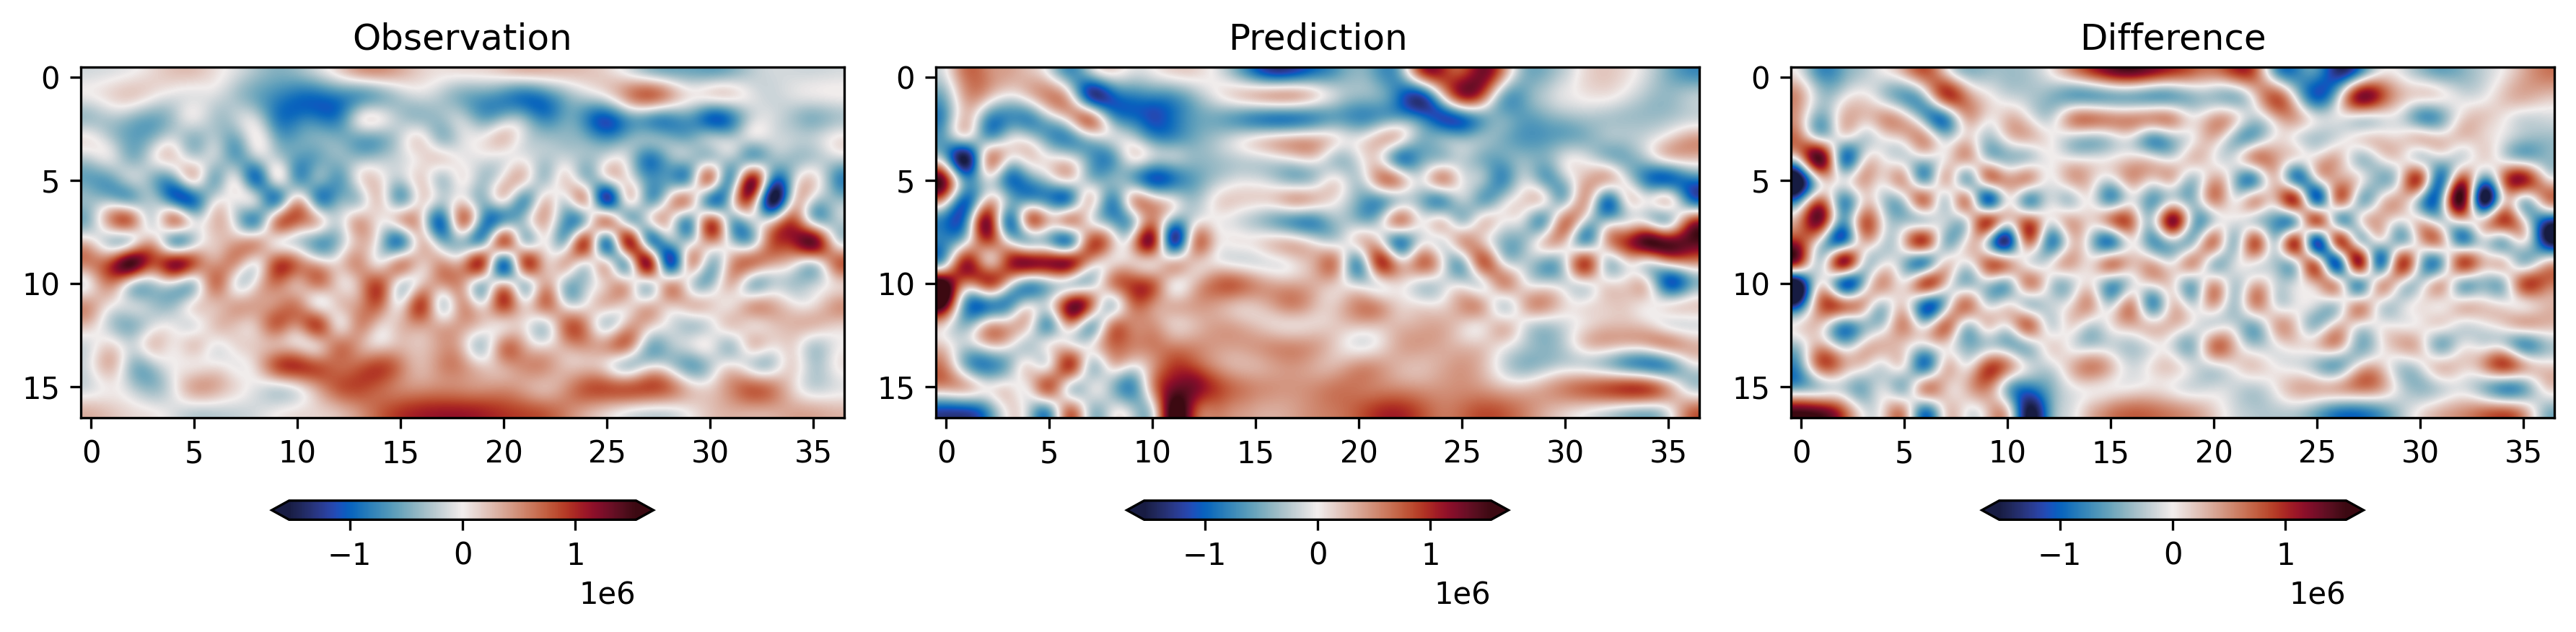

In [ ]:
quantity = "br"

fig, axes = plt.subplots(1, 3, dpi=300, figsize=(12, 3))

prediction = predictions[quantity][0]
observation = observations[quantity][0]

vmax = abs(observation).max()
kwargs = {"cmap": cmocean.cm.balance, "interpolation": "lanczos", "vmin": -vmax, "vmax": vmax}

im = axes[0].imshow(observation, **kwargs)
im2 = axes[1].imshow(prediction, **kwargs)
im3 = axes[2].imshow(observation - prediction, **kwargs)

axes[0].set_title("Observation")
axes[1].set_title("Prediction")
axes[2].set_title("Difference")

plt.colorbar(im, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im2, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im3, orientation="horizontal", shrink=0.5, extend="both")

plt.tight_layout()

### Comparison between large-scale and small-scale lengths

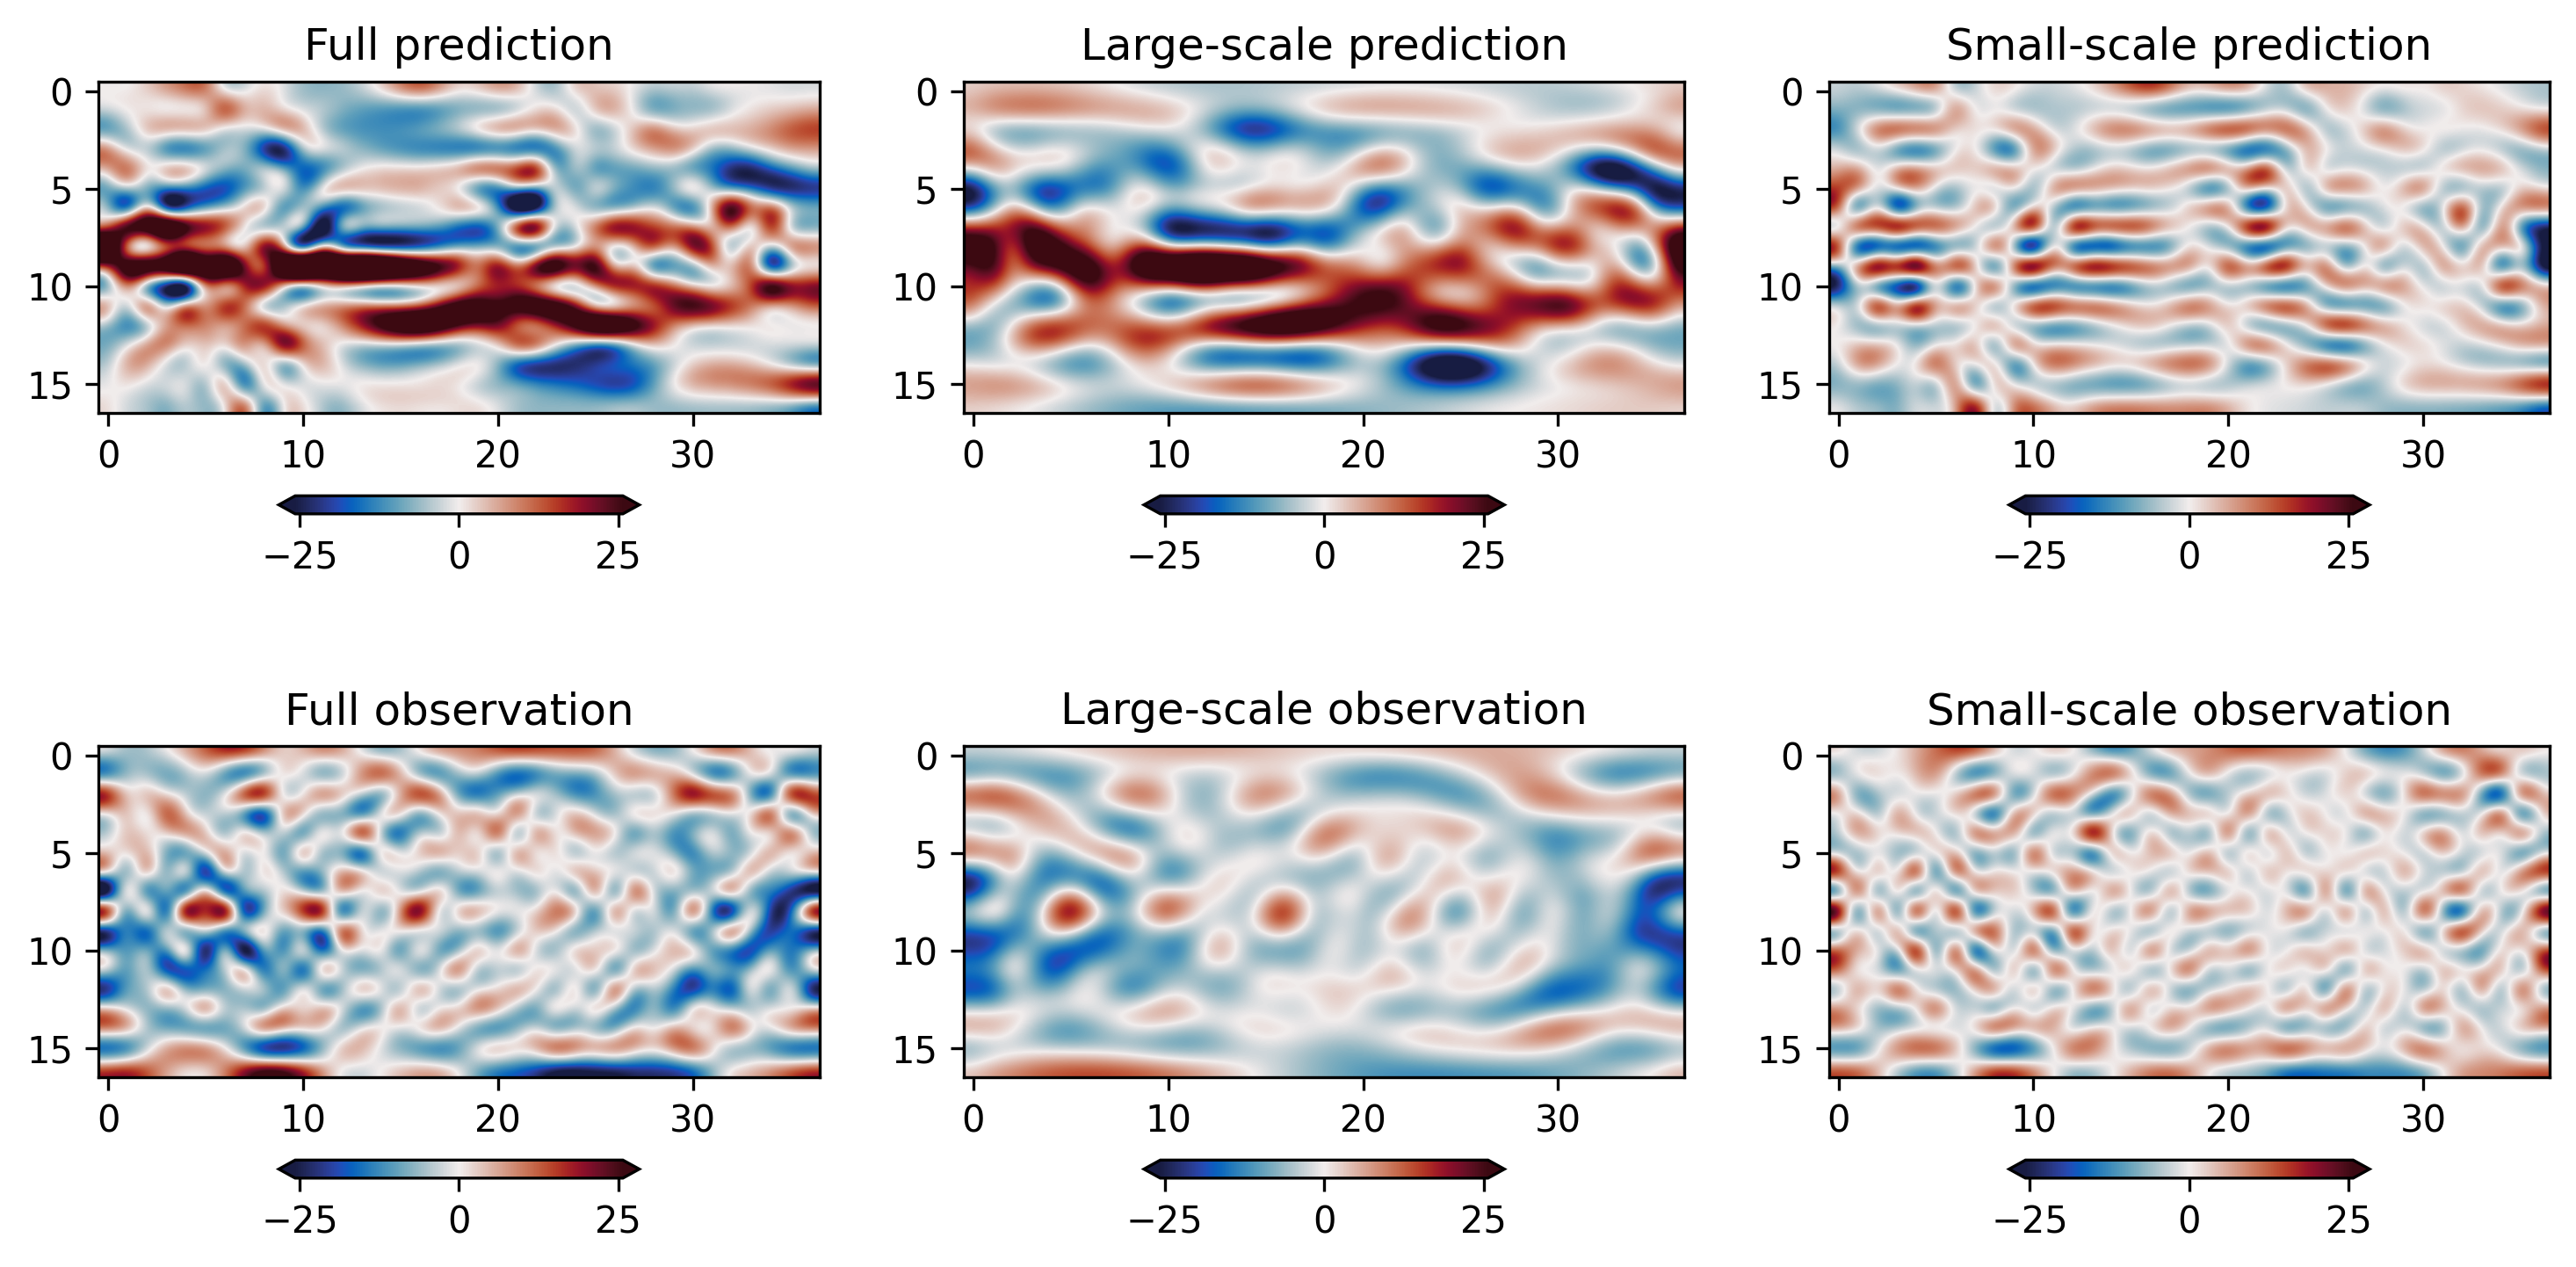

In [ ]:
from torch import tensor

quantity = "uφ"

prediction = predictions[quantity][0]
observation = observations[quantity][0]

xcos, xsin = pinns.spectral.forward(tensor(prediction), 13)
xcos_obs, xsin_obs = pinns.spectral.forward(tensor(observation), 13)

large_scale_prediction = pinns.spectral.backward(xcos, xsin, 13).detach().numpy()
large_scale_observation = pinns.spectral.backward(xcos_obs, xsin_obs, lmax=13).detach().numpy()

vmax = abs(observation).max()
kwargs = {"cmap": cmocean.cm.balance, "interpolation": "lanczos", "vmin": -vmax, "vmax": vmax}

fig, axes = plt.subplots(2, 3, dpi=300, figsize=(12, 6))

im0 = axes[0,0].imshow(prediction, **kwargs)
im1 = axes[0,1].imshow(large_scale_prediction, **kwargs)
im2 = axes[0,2].imshow(prediction - large_scale_prediction, **kwargs)

im3 = axes[1,0].imshow(observation, **kwargs)
im4 = axes[1,1].imshow(large_scale_observation, **kwargs)
im5 = axes[1,2].imshow(observation - large_scale_observation, **kwargs)

axes[0,0].set_title("Full prediction")
axes[0,1].set_title("Large-scale prediction")
axes[0,2].set_title("Small-scale prediction")

axes[1,0].set_title("Full observation")
axes[1,1].set_title("Large-scale observation")
axes[1,2].set_title("Small-scale observation")

plt.colorbar(im0, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im1, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im2, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im3, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im4, orientation="horizontal", shrink=0.5, extend="both")
plt.colorbar(im5, orientation="horizontal", shrink=0.5, extend="both")

### Spectrum

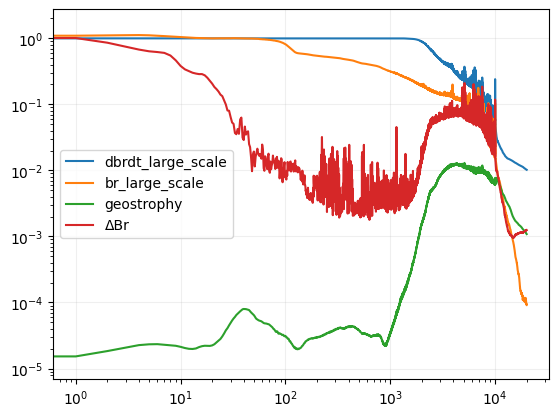

In [ ]:
for loss in pinns.history:
    plt.loglog(pinns.history[loss], label=loss)

plt.yscale("log")
plt.grid(alpha=0.2)
plt.legend()

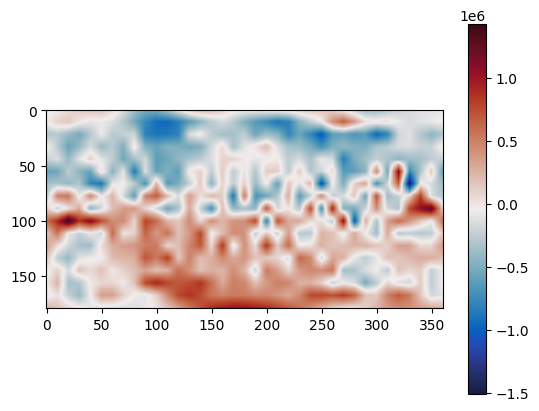

In [ ]:
values = Br[0,...]
points = numpy.meshgrid(*(thetas, phis), indexing="ij")

thetas_new = numpy.linspace(thetas[0], thetas[-1], 180)
phis_new = numpy.linspace(phis[0], phis[-1], 360)

points_new = numpy.meshgrid(*(thetas_new, phis_new), indexing="ij")

import scipy

interpolated_values = scipy.interpolate.RegularGridInterpolator((thetas, phis), values, method="linear")

plt.imshow(interpolated_values(points_new), cmap=cmocean.cm.balance)
plt.colorbar()